In [ ]:
import pandas as pd
import numpy as np
from bursty_dynamics.scores import calculate_scores
from bursty_dynamics.trains import train_detection, train_info, train_scores
from bursty_dynamics.visual import *

### Questions to explore
- are target paragraphs longer?
- audio features different for target paragraphs?
- within paragraph: emotion before sentence?

In [ ]:
paragraph_turns = pd.read_csv('../data/paragraph_turns_with_emotions.csv')

In [213]:
unique_episode_ids = paragraph_turns['episode_id'].nunique()
print(f"Number of unique episode_id: {unique_episode_ids}")

Number of unique episode_id: 3543


In [212]:
# with open('../data/final_episode_ids.txt', 'w') as file:
#     file.write(str(unique_episode_ids))

In [208]:
episodes_with_id = pd.read_csv("../data/episodes_with_id.csv")

In [215]:
len(episodes_with_id)

10496

In [209]:
filtered_episodes_with_id = episodes_with_id[episodes_with_id['episode_id'].isin(paragraph_turns['episode_id'].unique())]

In [216]:
len(filtered_episodes_with_id)

3543

In [218]:
filtered_episodes_with_id['numMainSpeakers'].describe()

count    3543.000000
mean        2.454982
std         0.870264
min         2.000000
25%         2.000000
50%         2.000000
75%         3.000000
max        10.000000
Name: numMainSpeakers, dtype: float64

In [219]:
len(paragraph_turns)

344732

In [222]:
category_counts = paragraph_turns['collectiveAction'].value_counts()
print(category_counts)

collectiveAction
1    329771
0     14961
Name: count, dtype: int64


### Inspecting duration of speaker turns

In [ ]:
filtered_episodes_with_id['avgTurnDuration'].describe()

In [ ]:
paragraph_turns['duration'].describe()

In [ ]:
filtered_durations = paragraph_turns['duration'].dropna() 
#filtered_durations = filtered_durations[filtered_durations > 43] # mean avgTurnDuration
filtered_durations = paragraph_turns['duration'].dropna().reset_index(drop=True)

sorted_durations = np.sort(filtered_durations)
cdf = np.arange(1, len(sorted_durations) + 1) / len(sorted_durations)

plt.plot(sorted_durations, cdf)
plt.xlabel('Duration')
plt.ylabel('Cumulative Probability')
plt.title('CDF of Durations')
plt.grid()
plt.show()

In [ ]:
# filtered_durations = paragraph_turns['sentence_length'].dropna() 
# #filtered_durations = filtered_durations[filtered_durations > 43] # mean avgTurnDuration
# filtered_durations = paragraph_turns['sentence_length'].dropna().reset_index(drop=True)

# sorted_durations = np.sort(filtered_durations)
# cdf = np.arange(1, len(sorted_durations) + 1) / len(sorted_durations)

# plt.plot(sorted_durations, cdf)
# plt.xlabel('Sentence length')
# plt.ylabel('Cumulative Probability')
# plt.title('CDF of Durations')
# plt.grid()
# plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Compute first derivative (slope)
first_derivative = np.gradient(cdf, filtered_durations)

# Compute second derivative (curvature)
second_derivative = np.gradient(first_derivative, filtered_durations)

# Filter indices where duration is greater than 43
valid_indices = np.where(filtered_durations > 43)[0]

if valid_indices.size > 0:
    # Find the index of the maximum second derivative among valid indices
    elbow_index = valid_indices[np.argmax(second_derivative[valid_indices])]
    elbow_duration = filtered_durations[elbow_index]

    print(f"Elbow point found at duration: {elbow_duration}")

    # Plot CDF with the detected elbow
    plt.plot(filtered_durations, cdf, marker='o', linestyle='-', label='CDF')
    plt.axvline(x=elbow_duration, color='r', linestyle='--', label=f'Elbow at {elbow_duration:.2f}')
    plt.xlabel('Duration')
    plt.ylabel('Cumulative Probability')
    plt.title('CDF with Elbow Point')
    plt.legend()
    plt.grid()
    plt.show()
else:
    print("No valid elbow point found with duration > 43.")

In [ ]:
#176.33
count = paragraph_turns[paragraph_turns['duration'] > 313.66].shape[0]
unique_episodes = paragraph_turns[paragraph_turns['duration'] > 313.66]['episode_id'].nunique()

print(f"Number of rows with duration over 313.66: {count}")
print(f"Number of unique episode_id values: {unique_episodes}")

In [ ]:
len(paragraph_turns[(paragraph_turns['duration'] > 313.66) & (paragraph_turns['collectiveAction'] == 0)])

In [ ]:
excluded_episode_ids = paragraph_turns.loc[paragraph_turns['duration'] > 313.66, 'episode_id'].unique()
better_paragraph_turns = paragraph_turns[~paragraph_turns['episode_id'].isin(excluded_episode_ids)]

In [ ]:
unique_episode_ids_better = better_paragraph_turns['episode_id'].nunique()
print(f"Number of unique episode_id in better_paragraph_turns: {unique_episode_ids_better}")

### Length of paragraph turns vs duration

In [ ]:
# Count the length of sentences in number of words
paragraph_turns['sentence_length'] = paragraph_turns['sentence'].apply(lambda x: len(str(x).split()))

In [ ]:
len(better_paragraph_turns)

In [ ]:
length_greater_than_20 = len(better_paragraph_turns[better_paragraph_turns['sentence_length'] > 20])
print(length_greater_than_20)

In [ ]:
unique_episode_ids_length_greater_than_20 = better_paragraph_turns[better_paragraph_turns['sentence_length'] > 120]['episode_id'].nunique()
print(f"Number of unique episode_id in better_paragraph_turns with sentence_length > 120: {unique_episode_ids_length_greater_than_20}")

In [ ]:
len(better_paragraph_turns[better_paragraph_turns['sentence_length'] > 20])

In [ ]:
count_collective_action_0 = len(better_paragraph_turns[(better_paragraph_turns['sentence_length'] > 20) & (better_paragraph_turns['collectiveAction'] == 0)])
print(count_collective_action_0)

In [ ]:
paragraph_turns['sentence_length'].describe()

In [ ]:
better_paragraph_turns['sentence_length'].describe()

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(paragraph_turns['sentence_length'], paragraph_turns['duration'], alpha=0.5)
plt.title('Paragraph Length vs Duration')
plt.xlabel('Paragraph Length (words)')
plt.ylabel('Duration (seconds)')
plt.show()

In [ ]:
better_paragraph_turns.to_csv('../data/better_paragraph_turns.csv', index=False)

### Burstiness

In [ ]:
better_paragraph_turns = pd.read_csv('../data/better_paragraph_turns.csv')

In [ ]:
ca_paragraph_turns = paragraph_turns[paragraph_turns['collectiveAction'] == 0]
len(ca_paragraph_turns)

In [ ]:
ca_paragraph_turns = ca_paragraph_turns.dropna(subset=['startTime'])
len(ca_paragraph_turns)

In [ ]:
episode_counts = ca_paragraph_turns.groupby('episode_id').size()  # Count occurrences of each episode_id
valid_episodes = episode_counts[episode_counts >= 3].index  # Get episode_ids with at least 3 occurrences
ca_paragraph_turns = ca_paragraph_turns[ca_paragraph_turns['episode_id'].isin(valid_episodes)]
len(ca_paragraph_turns)

In [ ]:
start_reference = pd.Timestamp("2020-01-01 00:00:00")

# Convert 'startTime' (which is in seconds) to proper datetime format
ca_paragraph_turns['startTime'] = start_reference + pd.to_timedelta(ca_paragraph_turns['startTime'], unit='s')

In [ ]:
score_df = calculate_scores(ca_paragraph_turns, subject_id = 'episode_id', time_col = 'startTime')
score_df.tail()

In [ ]:
len(score_df)

In [ ]:
num_nan_mc = score_df['BP'].isna().sum()
print(f"Number of NaN values in score_df['BP']: {num_nan_mc}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the histogram values
values, bins, patches = plt.hist(score_df["BP"], bins=30, alpha=0.7, color="green", edgecolor='white')

# Calculate the total number of episodes
total_episodes = len(score_df["BP"])

# Convert counts to percentages
percentages = (values / total_episodes) * 100

# Get the current axis
ax = plt.gca()

# Set the y-axis ticks to the percentage values
ax.set_yticks(np.linspace(0, max(values), 5))
ax.set_yticklabels([f'{p:.2f}%' for p in np.linspace(0, max(percentages), 5)])

# Add the title and axis labels
plt.title("Burstiness Distribution")
plt.xlabel("Burstiness (A)")
plt.ylabel("Percentage (%)")

# Show the plot
plt.show()

In [ ]:
num_bp_greater_than_zero = (score_df["BP"] > 0).sum()
print(f"Number of entries in score_df['BP'] > 0: {num_bp_greater_than_zero}")

In [ ]:
score_df = score_df.merge(episodes_with_id[['episode_id', 'category1']], on='episode_id', how='left')
score_df.rename(columns={'category1': 'Group'}, inplace=True)
score_df.head()

In [ ]:
histogram(score_df, hist='BP', set_axis=True, hue='Group')

In [ ]:
train_df = train_detection(ca_paragraph_turns, subject_id = 'episode_id', time_col = 'startTime', max_iet=30, time_unit='seconds')

In [ ]:
# Step 1: Get unique (episode_id, train_id) pairs
unique_combinations = train_df[['episode_id', 'train_id']].drop_duplicates()

# Step 2: Assign new unique train_id values
unique_combinations['new_train_id'] = range(1, len(unique_combinations) + 1)

# Step 3: Merge back to update train_id
train_df = train_df.merge(unique_combinations, on=['episode_id', 'train_id'], how='left')

# Step 4: Replace old train_id with new_train_id
train_df['train_id'] = train_df['new_train_id']

# Step 5: Drop the temporary column
train_df = train_df.drop(columns=['new_train_id'])

In [ ]:
unique_episode_ids_train_df = train_df['episode_id'].nunique()
print(f"Number of unique episode_id in train_df: {unique_episode_ids_train_df}")

In [ ]:
average_trains_per_episode = train_df.groupby('episode_id')['train_id'].nunique().mean()
print(f"Average number of trains per episode_id: {average_trains_per_episode}")

### CA paragraphs in-depth

In [135]:
paragraph_turns = pd.read_csv('../data/paragraph_turns_concatenated_lists_clean.csv')
#paragraph_turns = pd.read_csv('../data/paragraph_turns_with_emotions.csv')
len(paragraph_turns)

344732

In [136]:
ca_paragraph_turns = paragraph_turns[paragraph_turns['collectiveAction'] == 0]
ca_paragraph_turns['collectiveActionMulti']

8                                  [2.0, 3.0]
49                                      [0.0]
110                                     [0.0]
115       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
120            [3.0, 0.0, 0.0, 0.0, 1.0, 0.0]
                         ...                 
344485                                  [0.0]
344493                                  [0.0]
344543                                  [3.0]
344591                                  [1.0]
344626                                  [3.0]
Name: collectiveActionMulti, Length: 14961, dtype: object

Fix (fake) lists

In [137]:
import ast

In [138]:
def clean_list_string(x):
    try:
        # Remove any non-numeric characters that might be causing issues
        x = x.replace('nan', 'None')  # Replace 'nan' with 'None' for proper evaluation
        return ast.literal_eval(x) if isinstance(x, str) else x
    except (ValueError, SyntaxError) as e:
        print(f"Error processing: {x} -> {e}")
        return []
paragraph_turns['collectiveActionMulti'] = paragraph_turns['collectiveActionMulti'].apply(clean_list_string)

In [139]:
# Remove NaNs from lists in the 'collectiveActionMulti' column
paragraph_turns['collectiveActionMulti'] = paragraph_turns['collectiveActionMulti'].apply(
    lambda x: [i for i in x if pd.notna(i)]  # Remove NaN values
)

In [140]:
ca_paragraph_turns = paragraph_turns[paragraph_turns['collectiveAction'] == 0]
len(ca_paragraph_turns) # 14961
ca_paragraph_turns['collectiveActionMulti']

8                                  [2.0, 3.0]
49                                      [0.0]
110                                     [0.0]
115       [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
120            [3.0, 0.0, 0.0, 0.0, 1.0, 0.0]
                         ...                 
344485                                  [0.0]
344493                                  [0.0]
344543                                  [3.0]
344591                                  [1.0]
344626                                  [3.0]
Name: collectiveActionMulti, Length: 14961, dtype: object

In [70]:
# # Sample data to simulate your scenario
# dummy = pd.DataFrame({
#     'collectiveActionMulti': [
#         [3.0, np.nan], [2.0, np.nan], [0.0, np.nan],
#         [0.0, 0.0, np.nan], [0.0, 0.0, 0.0, 0.0, np.nan],
#         [0.0, 0.0, 0.0, 3.0, np.nan], [3.0, 3.0, np.nan],
#         [0.0, 0.0, 0.0, np.nan], [2.0, 0.0, 0.0, np.nan]
#     ]
# })

# # Remove NaN values from the lists in the 'collectiveActionMulti' column
# dummy['collectiveActionMulti'] = dummy['collectiveActionMulti'].apply(
#     lambda x: [i for i in x if pd.notna(i)]  # Remove NaN values
# )

# dummy

In [83]:
unique_counts = ca_paragraph_turns['collectiveActionMulti'].value_counts()

with open("../data/ca_patterns.txt", "w", encoding="utf-8") as f:
    for pattern, count in unique_counts.items():
        f.write(f"{pattern}: {count}\n")

In [ ]:
# rows_per_episode = ca_paragraph_turns.groupby('episode_id').size()
# rows_per_episode.describe()

In [ ]:
# rows_per_episode_sorted = rows_per_episode.sort_values(ascending=False)
# rows_per_episode_sorted

In [ ]:
# # Function to clean up tuples with NaN values
# def clean_tuple(tup):
#     # Remove NaN values
#     cleaned = tuple(x for x in tup if not pd.isna(x))
#     # If it becomes empty, keep as NaN (optional)
#     return cleaned if cleaned else (np.nan,)

# # Apply the function to the column
# ca_paragraph_turns['collectiveActionMulti_tuple'] = ca_paragraph_turns['collectiveActionMulti_tuple'].apply(clean_tuple)

# # Recalculate value counts
# category_counts = ca_paragraph_turns['collectiveActionMulti_tuple'].value_counts()
# print(category_counts)

### Transitions
- transition matrix: go through each list and count number of transitions (0->1 transition)
- how many times each transition type happens per paragraph (on avg) - two barplot: one pos, one neg 
- sum probabilities by row (transition 0 to 1 dominates over 2 to 3)
- also count p, p+1?

In [204]:
with open('../data/ca_patterns.txt', 'r', encoding='utf-8') as file:
    ca_patterns = file.read()

In [205]:
file_path = "../data/ca_patterns.txt"
df = pd.read_csv(file_path, sep="]: ", engine="python", names=["Pattern", "Count"], header=None)
df["Pattern"] = df["Pattern"].str.replace(r"^\[|\]$", "", regex=True)
df["Count"] = df["Count"].astype(int)
df.head(10)

,Pattern,Count
0,0.0,7037
1,2.0,1731
2,3.0,1674
3,"0.0, 0.0",955
4,1.0,837
5,"0.0, 0.0, 0.0",271
6,"0.0, 3.0",145
7,"2.0, 0.0",140
8,"3.0, 0.0",138
9,"3.0, 3.0",130


In [206]:
# Define possible state values
states = [0.0, 1.0, 2.0, 3.0]
state_index = {state: i for i, state in enumerate(states)}  # Mapping states to indices

# Initialize transition matrix
transition_matrix = np.zeros((len(states), len(states)), dtype=int)
transition_matrix

array([[0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0],
       [0, 0, 0, 0]])

In [207]:
# Function to process patterns
def update_matrix(pattern, count):
    transitions = pattern.split(", ")  # Split the pattern into states
    transitions = [float(x) for x in transitions]  # Convert to float
    
    for i in range(len(transitions) - 1):  # Iterate through transitions
        from_state = transitions[i]
        to_state = transitions[i + 1]
        transition_matrix[state_index[from_state], state_index[to_state]] += count

# Process each row
for _, row in df.iterrows():
    update_matrix(row["Pattern"], row["Count"])

# Convert to DataFrame for better readability
transition_df = pd.DataFrame(transition_matrix, index=states, columns=states)

# Display the transition matrix
transition_df

,0.0,1.0,2.0,3.0
0.0,3715,422,415,490
1.0,333,234,86,101
2.0,435,92,232,165
3.0,448,140,147,385


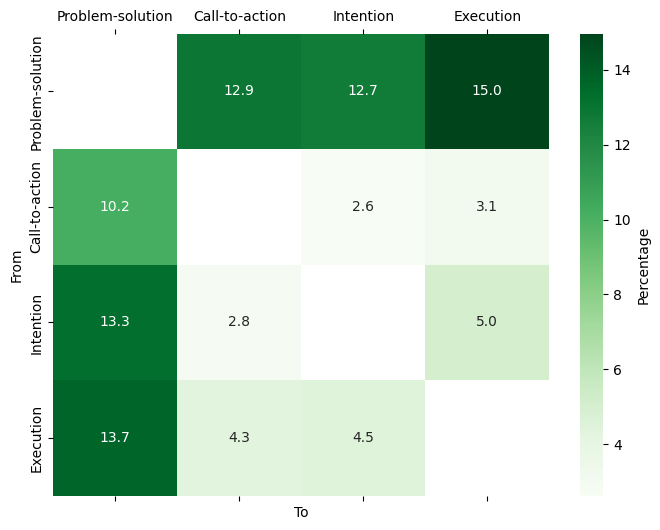

In [ ]:
labels = [
    "Problem-solution",   # 0.0
    "Call-to-action",     # 1.0
    "Intention",          # 2.0
    "Execution"           # 3.0
]

masked_transition_df = transition_df.astype(float)
np.fill_diagonal(masked_transition_df.values, np.nan) # set diagonal values to NaN

# Calculate the total number of transitions (sum of all non-diagonal elements)
total_transitions = masked_transition_df.sum().sum()
# Convert the counts to percentages
masked_transition_df_percent = (masked_transition_df / total_transitions) * 100

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(masked_transition_df_percent, annot=True, fmt=".1f", cmap="Greens", xticklabels=labels, yticklabels=labels, mask=np.isnan(masked_transition_df))

# Adjust colorbar with a custom label
colorbar = heatmap.collections[0].colorbar
colorbar.set_label('Percentage')

plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)
plt.xlabel("To")
plt.ylabel("From")
plt.show()


Should the percentages above the diagonal be % of total transitions (is 0 to 0 a transition?) or just escalations/progressions?

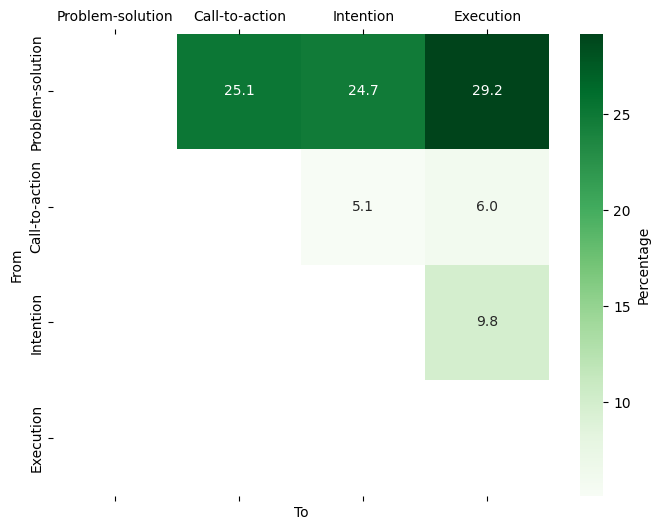

In [96]:
masked_transition_df = transition_df.astype(float)

# Set diagonal values to NaN (self-transitions)
np.fill_diagonal(masked_transition_df.values, np.nan)
# Create a mask for the lower triangle and diagonal
mask = np.tril(np.ones_like(masked_transition_df, dtype=bool))
# Calculate the total number of transitions (sum of upper triangle only)
upper_triangle = np.triu(masked_transition_df, k=1)  # k=1 excludes the diagonal
total_transitions = upper_triangle.sum()
# Convert the counts to percentages
masked_transition_df_percent = (masked_transition_df / total_transitions) * 100
# Apply the mask (set diagonal and lower triangle to NaN)
masked_transition_df_percent[mask] = np.nan
# np.fill_diagonal(masked_transition_df.values, np.nan)

# # Calculate the total number of transitions (sum of all non-diagonal elements)
# total_transitions = masked_transition_df.sum().sum()
# # Convert the counts to percentages
# masked_transition_df_percent = (masked_transition_df / total_transitions) * 100

# # Create a mask for diagonal and lower triangle
# mask = np.tril(np.ones_like(masked_transition_df_percent, dtype=bool))
# # Apply mask (set diagonal and lower triangle to NaN)
# masked_transition_df_percent[mask] = np.nan

plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(masked_transition_df_percent, annot=True, fmt=".1f", cmap="Greens", xticklabels=labels, yticklabels=labels, mask=mask)

colorbar = heatmap.collections[0].colorbar
colorbar.set_label('Percentage')

plt.gca().tick_params(axis='x', top=True, labeltop=True, labelbottom=False)
plt.xlabel("To")
plt.ylabel("From")
plt.show()

Barplots: how many times each transition happens per paragraph (on avg)

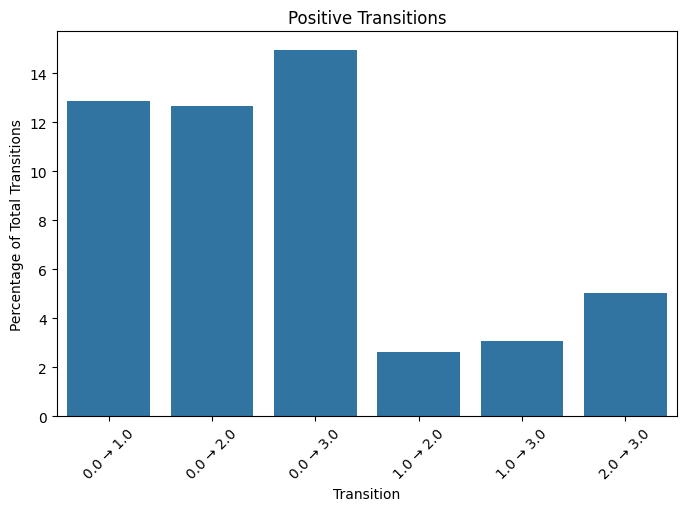

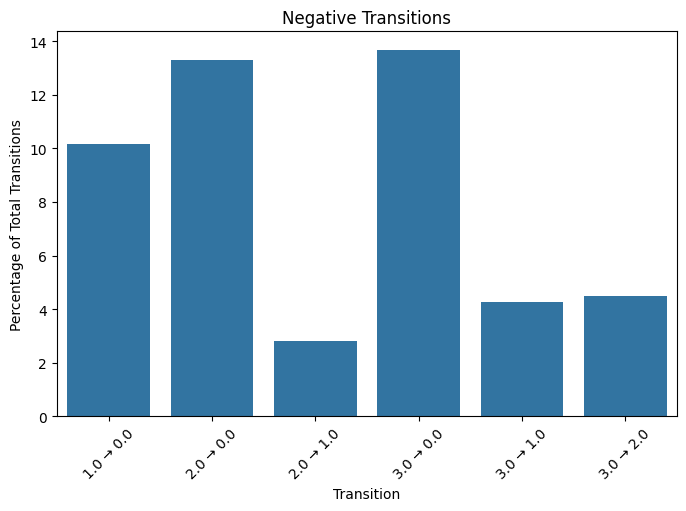

In [151]:
df = ca_paragraph_turns  # Your DataFrame

# Function to count transitions
def count_transitions(sequences):
    pos_transitions = {}
    neg_transitions = {}
    total_transitions = 0

    for seq in sequences:
        for i in range(len(seq) - 1):
            prev, curr = seq[i], seq[i+1]
            if prev != curr:  # Ignore same-value transitions
                transition = (prev, curr)
                total_transitions += 1
                if prev < curr:  # Positive transition
                    pos_transitions[transition] = pos_transitions.get(transition, 0) + 1
                else:  # Negative transition
                    neg_transitions[transition] = neg_transitions.get(transition, 0) + 1

    return pos_transitions, neg_transitions, total_transitions

# Get transition counts and total transitions
pos_transitions, neg_transitions, total_transitions = count_transitions(df['collectiveActionMulti'])

# Convert to DataFrame for plotting
df_pos = pd.DataFrame(list(pos_transitions.items()), columns=['Transition', 'Count'])
df_neg = pd.DataFrame(list(neg_transitions.items()), columns=['Transition', 'Count'])

# Compute percentage
df_pos['Percentage'] = (df_pos['Count'] / total_transitions) * 100
df_neg['Percentage'] = (df_neg['Count'] / total_transitions) * 100

df_pos = df_pos.sort_values(by=['Transition'])
df_neg = df_neg.sort_values(by=['Transition'])

# Plot positive transitions as percentage
plt.figure(figsize=(8, 5))
sns.barplot(x=[f"{t[0]} → {t[1]}" for t in df_pos['Transition']], y=df_pos['Percentage'])
plt.title('Positive Transitions')
plt.ylabel('Percentage of Total Transitions')
plt.xlabel('Transition')
plt.xticks(rotation=45)
plt.show()

# Plot negative transitions as percentage
plt.figure(figsize=(8, 5))
sns.barplot(x=[f"{t[0]} → {t[1]}" for t in df_neg['Transition']], y=df_neg['Percentage'])
plt.title('Negative Transitions')
plt.ylabel('Percentage of Total Transitions')
plt.xlabel('Transition')
plt.xticks(rotation=45)
plt.show()

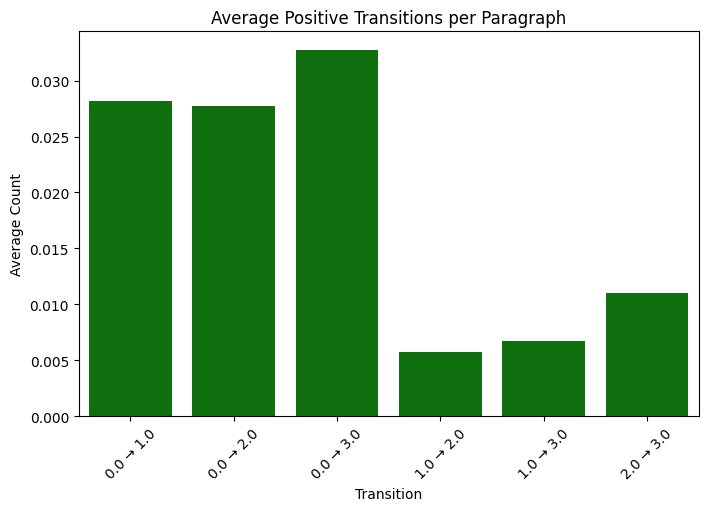

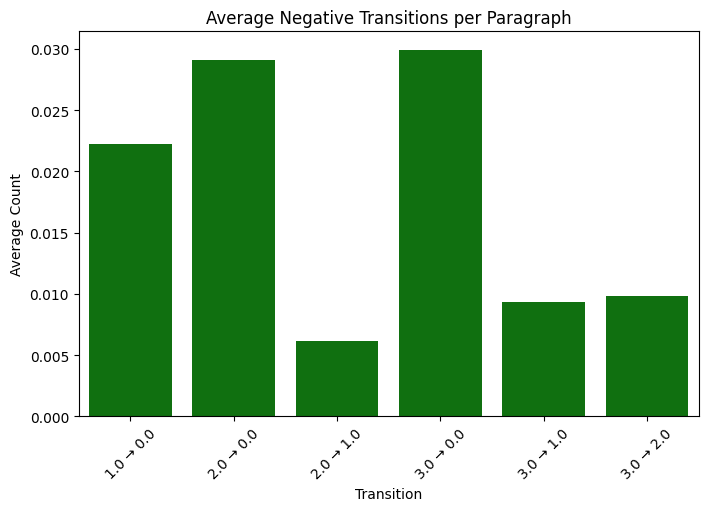

In [155]:
# Function to count transitions per paragraph
def count_transitions_per_paragraph(sequences):
    pos_transitions_per_paragraph = []
    neg_transitions_per_paragraph = []

    for seq in sequences:
        pos_transitions = {}
        neg_transitions = {}

        for i in range(len(seq) - 1):
            prev, curr = seq[i], seq[i+1]
            if prev != curr:  # Ignore self-transitions (e.g., 0→0, 1→1)
                transition = (prev, curr)
                if prev < curr:  # Positive transition
                    pos_transitions[transition] = pos_transitions.get(transition, 0) + 1
                else:  # Negative transition
                    neg_transitions[transition] = neg_transitions.get(transition, 0) + 1
        
        # Store transition counts per paragraph
        pos_transitions_per_paragraph.append(pos_transitions)
        neg_transitions_per_paragraph.append(neg_transitions)

    return pos_transitions_per_paragraph, neg_transitions_per_paragraph

# Get per-paragraph transition counts
pos_per_paragraph, neg_per_paragraph = count_transitions_per_paragraph(df['collectiveActionMulti'])

# Aggregate average transition counts per paragraph
def average_transitions(transition_counts):
    total_counts = {}
    num_paragraphs = len(transition_counts)

    for transitions in transition_counts:
        for transition, count in transitions.items():
            total_counts[transition] = total_counts.get(transition, 0) + count

    # Compute the average per paragraph
    avg_counts = {t: count / num_paragraphs for t, count in total_counts.items()}
    return avg_counts

avg_pos_transitions = average_transitions(pos_per_paragraph)
avg_neg_transitions = average_transitions(neg_per_paragraph)

# Convert to DataFrame for plotting
df_avg_pos = pd.DataFrame(list(avg_pos_transitions.items()), columns=['Transition', 'Avg Count'])
df_avg_neg = pd.DataFrame(list(avg_neg_transitions.items()), columns=['Transition', 'Avg Count'])

df_avg_pos = df_avg_pos.sort_values(by=['Transition'])
df_avg_neg = df_avg_neg.sort_values(by=['Transition'])

# Plot positive transitions (average per paragraph)
plt.figure(figsize=(8, 5))
sns.barplot(x=[f"{t[0]} → {t[1]}" for t in df_avg_pos['Transition']], y=df_avg_pos['Avg Count'], color='green') 
plt.title('Average Positive Transitions per Paragraph')
plt.ylabel('Average Count')
plt.xlabel('Transition')
plt.xticks(rotation=45)
plt.show()

# Plot negative transitions (average per paragraph)
plt.figure(figsize=(8, 5))
sns.barplot(x=[f"{t[0]} → {t[1]}" for t in df_avg_neg['Transition']], y=df_avg_neg['Avg Count'], color='green') 
plt.title('Average Negative Transitions per Paragraph')
plt.ylabel('Average Count')
plt.xlabel('Transition')
plt.xticks(rotation=45)
plt.show()

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

df = ca_paragraph_turns  # Your DataFrame

# Function to count transitions
def count_transitions(sequences):
    pos_transitions = {}
    neg_transitions = {}
    total_transitions = 0

    for seq in sequences:
        for i in range(len(seq) - 1):
            prev, curr = seq[i], seq[i+1]
            if prev != curr:  # Ignore same-value transitions
                transition = (prev, curr)
                total_transitions += 1
                if prev < curr:  # Positive transition
                    pos_transitions[transition] = pos_transitions.get(transition, 0) + 1
                else:  # Negative transition
                    neg_transitions[transition] = neg_transitions.get(transition, 0) + 1

    return pos_transitions, neg_transitions, total_transitions

# Get transition counts and total transitions
pos_transitions, neg_transitions, total_transitions = count_transitions(df['collectiveActionMulti'])

# Convert to DataFrame for plotting
df_pos = pd.DataFrame(list(pos_transitions.items()), columns=['Transition', 'Count'])
df_neg = pd.DataFrame(list(neg_transitions.items()), columns=['Transition', 'Count'])

# Compute percentage
df_pos['Percentage'] = (df_pos['Count'] / total_transitions) * 100
df_neg['Percentage'] = (df_neg['Count'] / total_transitions) * 100

df_all = pd.concat([df_pos, df_neg]).reset_index(drop=True)  # Merge both positive & negative

# Sum of all probabilities
total_probability = df_all['Percentage'].sum()  # Should be 100%

# Function to compare all transitions
def compare_all_transitions(df_all):
    results = []
    transitions = df_all['Transition'].tolist()
    
    for i, transition_a in enumerate(transitions):
        prob_a = df_all[df_all['Transition'] == transition_a]['Percentage'].values[0]
        for j, transition_b in enumerate(transitions):
            if i >= j:  # Avoid duplicate pairs (a, b) and (b, a)
                continue
            prob_b = df_all[df_all['Transition'] == transition_b]['Percentage'].values[0]
            
            # Check dominance (simple comparison)
            dominance = prob_a > prob_b
            
            # Statistical test (Binomial test using scipy.stats.binom)
            trials = prob_a + prob_b
            success = prob_a
            p_value = binom.sf(success - 1, trials, 0.5)  # One-sided test (success >= prob_a)
            
            # Record the result
            results.append({
                'Transition A': transition_a,
                'Probability A': prob_a,
                'Transition B': transition_b,
                'Probability B': prob_b,
                'Dominance': dominance,
                'P-Value': p_value
            })
    
    return pd.DataFrame(results)

# Compare all transitions
comparison_results = compare_all_transitions(df_all)

# Display the results (you can filter for significant dominance or specific criteria)
print(comparison_results)

   Transition A  Probability A Transition B  Probability B  Dominance  P-Value
0    (2.0, 3.0)       5.039707   (0.0, 1.0)      12.889432      False      NaN
1    (2.0, 3.0)       5.039707   (0.0, 3.0)      14.966402      False      NaN
2    (2.0, 3.0)       5.039707   (0.0, 2.0)      12.675626      False      NaN
3    (2.0, 3.0)       5.039707   (1.0, 2.0)       2.626756       True      NaN
4    (2.0, 3.0)       5.039707   (1.0, 3.0)       3.084911       True      NaN
..          ...            ...          ...            ...        ...      ...
61   (2.0, 1.0)       2.810018   (2.0, 0.0)      13.286500      False      NaN
62   (2.0, 1.0)       2.810018   (3.0, 2.0)       4.489921      False      NaN
63   (3.0, 1.0)       4.276115   (2.0, 0.0)      13.286500      False      NaN
64   (3.0, 1.0)       4.276115   (3.0, 2.0)       4.489921      False      NaN
65   (2.0, 0.0)      13.286500   (3.0, 2.0)       4.489921       True      NaN

[66 rows x 6 columns]


In [192]:
# Ensure that 'Transition A' and 'Transition B' are tuples like (0.0, 1.0)
dominant_transitions = comparison_results

# Filter out rows where Transition A or Transition B is in descending order (i.e., x[0] > x[1])
dominant_transitions = dominant_transitions[
    (dominant_transitions['Transition A'].apply(lambda x: x[0] <= x[1])) &
    (dominant_transitions['Transition B'].apply(lambda x: x[0] <= x[1]))
]
dominant_transitions.head(40)

,Transition A,Probability A,Transition B,Probability B,Dominance,P-Value
0,"(2.0, 3.0)",5.039707,"(0.0, 1.0)",12.889432,False,NaN
1,"(2.0, 3.0)",5.039707,"(0.0, 3.0)",14.966402,False,NaN
2,"(2.0, 3.0)",5.039707,"(0.0, 2.0)",12.675626,False,NaN
3,"(2.0, 3.0)",5.039707,"(1.0, 2.0)",2.626756,True,NaN
4,"(2.0, 3.0)",5.039707,"(1.0, 3.0)",3.084911,True,NaN
11,"(0.0, 1.0)",12.889432,"(0.0, 3.0)",14.966402,False,NaN
12,"(0.0, 1.0)",12.889432,"(0.0, 2.0)",12.675626,True,NaN
13,"(0.0, 1.0)",12.889432,"(1.0, 2.0)",2.626756,True,NaN
14,"(0.0, 1.0)",12.889432,"(1.0, 3.0)",3.084911,True,NaN
21,"(0.0, 3.0)",14.966402,"(0.0, 2.0)",12.675626,True,NaN


/var/folders/z_/3vpzgjpj4dv90c8dxq0x3ww80000gn/T/ipykernel_49217/647438497.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


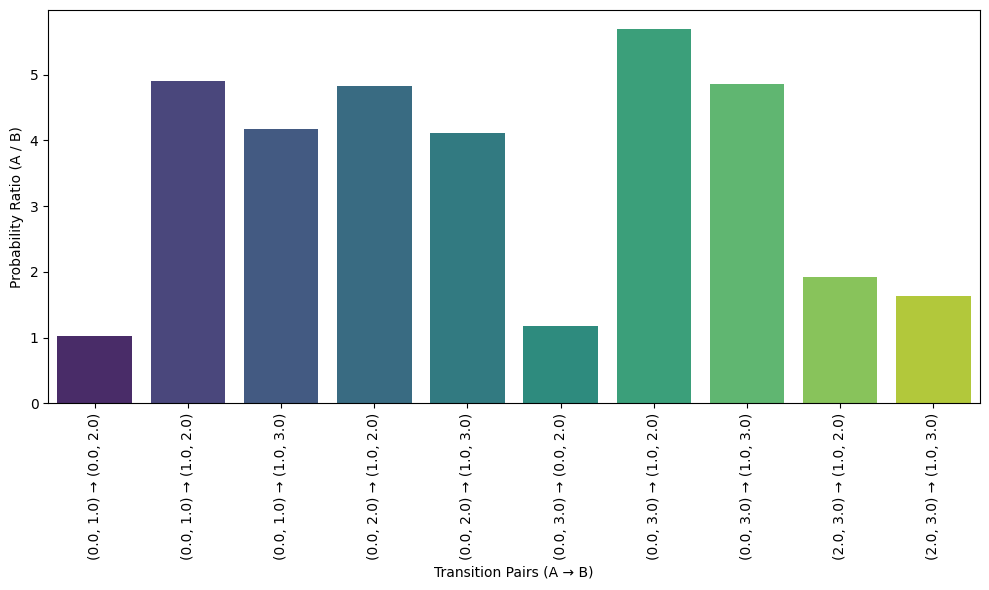

In [194]:
# Calculate the Probability Ratio
dominant_transitions['Dominance Metric'] = dominant_transitions['Probability A'] / dominant_transitions['Probability B']

# Filter for transitions where A is more likely than B (ratio > 1)
dominant_transitions = dominant_transitions[dominant_transitions['Dominance Metric'] > 1]

# Create the transition pair labels
dominant_transitions['Transition Pair'] = dominant_transitions['Transition A'].apply(str) + " → " + dominant_transitions['Transition B'].apply(str)

# Sort the DataFrame by the 'Dominance Metric' in descending order (higher ratio = more likely)
dominant_transitions = dominant_transitions.sort_values(by='Transition Pair')

# Plot the transitions based on the new metric (Probability Ratio)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=dominant_transitions['Transition Pair'], 
    y=dominant_transitions['Dominance Metric'],
    palette="viridis"
)

# Customize the plot
#plt.title("Dominant Progressions Based on Probability Ratio")
plt.ylabel("Probability Ratio (A / B)")
plt.xlabel("Transition Pairs (A → B)")
plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

### Go emotions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
paragraph_turns_with_emotions = pd.read_csv('../data/paragraph_turns_with_emotions.csv')
len(paragraph_turns_with_emotions)

344732

In [3]:
emotion_columns = ['gratitude', 'excitement', 'joy', 'approval', 'admiration', 'relief', 'caring',
                   'optimism', 'realization', 'surprise', 'pride', 'desire', 'love', 'annoyance', 'amusement',
                   'confusion', 'sadness', 'curiosity', 'fear', 'disapproval', 'nervousness', 'disgust',
                   'disappointment', 'anger', 'grief', 'remorse', 'embarrassment', 'neutral']
emotion_summary = paragraph_turns_with_emotions[emotion_columns].describe()
mean_plus_std = emotion_summary.loc['mean'] + emotion_summary.loc['std']
emotion_summary.loc['mean+std'] = mean_plus_std
emotion_summary

,gratitude,excitement,joy,approval,admiration,relief,caring,optimism,realization,surprise,...,fear,disapproval,nervousness,disgust,disappointment,anger,grief,remorse,embarrassment,neutral
count,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,...,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000,344732.000000
mean,0.027624,0.014369,0.015965,0.161415,0.057727,0.002332,0.013197,0.023798,0.038118,0.010350,...,0.005269,0.038506,0.002169,0.004462,0.016407,0.008518,0.000810,0.004114,0.002030,0.490817
std,0.139897,0.058008,0.070945,0.201537,0.169501,0.006233,0.062817,0.078988,0.068718,0.062779,...,0.042267,0.108590,0.014633,0.029917,0.051511,0.048594,0.002384,0.044328,0.014714,0.295206
min,0.000048,0.000193,0.000260,0.001814,0.000314,0.000098,0.000204,0.000621,0.001591,0.000149,...,0.000110,0.000526,0.000062,0.000284,0.000482,0.000219,0.000084,0.000069,0.000093,0.002112
25%,0.000741,0.001365,0.001262,0.023229,0.002513,0.000518,0.001197,0.003413,0.008853,0.000940,...,0.000662,0.003212,0.000334,0.000961,0.001905,0.001061,0.000261,0.000309,0.000414,0.244464
50%,0.001229,0.002658,0.002276,0.074530,0.005277,0.001021,0.002152,0.006193,0.019202,0.001539,...,0.001009,0.005169,0.000551,0.001382,0.003380,0.001671,0.000382,0.000497,0.000667,0.497730
75%,0.002974,0.005841,0.005260,0.210702,0.016465,0.002100,0.004888,0.013828,0.038406,0.003279,...,0.001661,0.016507,0.001135,0.002309,0.009222,0.003037,0.000631,0.000979,0.001354,0.737811
max,0.993567,0.850691,0.919166,0.933444,0.964216,0.306295,0.924108,0.960292,0.889589,0.903318,...,0.916430,0.901174,0.655694,0.863699,0.871775,0.860903,0.116829,0.854080,0.840622,0.973132
mean+std,0.167521,0.072378,0.086911,0.362952,0.227228,0.008564,0.076013,0.102787,0.106836,0.073130,...,0.047537,0.147096,0.016802,0.034378,0.067918,0.057112,0.003194,0.048442,0.016744,0.786022


Using the optimized threshold per label for the one that gives the optimum F1 metrics 

In [ ]:
# data = """
# admiration	0.940	0.651	0.776	0.708	0.678	504	0.25
# amusement	0.982	0.781	0.890	0.832	0.825	264	0.45
# anger	0.959	0.454	0.601	0.517	0.502	198	0.15
# annoyance	0.864	0.243	0.619	0.349	0.328	320	0.10
# approval	0.926	0.432	0.442	0.437	0.397	351	0.30
# caring	0.972	0.426	0.385	0.405	0.391	135	0.40
# confusion	0.974	0.548	0.412	0.470	0.462	153	0.55
# curiosity	0.943	0.473	0.711	0.568	0.552	284	0.25
# desire	0.985	0.518	0.530	0.524	0.516	83	0.25
# disappointment	0.974	0.562	0.298	0.390	0.398	151	0.40
# disapproval	0.941	0.414	0.468	0.439	0.409	267	0.30
# disgust	0.978	0.523	0.463	0.491	0.481	123	0.20
# embarrassment	0.994	0.567	0.459	0.507	0.507	37	0.10
# excitement	0.981	0.500	0.417	0.455	0.447	103	0.35
# fear	0.991	0.712	0.667	0.689	0.685	78	0.40
# gratitude	0.990	0.957	0.889	0.922	0.917	352	0.45
# grief	0.999	0.333	0.333	0.333	0.333	6	0.05
# joy	0.978	0.623	0.646	0.634	0.623	161	0.40
# love	0.982	0.740	0.899	0.812	0.807	238	0.25
# nervousness	0.996	0.571	0.348	0.432	0.444	23	0.25
# optimism	0.971	0.580	0.565	0.572	0.557	186	0.20
# pride	0.998	0.875	0.438	0.583	0.618	16	0.10
# realization	0.961	0.270	0.262	0.266	0.246	145	0.15
# relief	0.992	0.152	0.636	0.246	0.309	11	0.05
# remorse	0.991	0.541	0.946	0.688	0.712	56	0.10
# sadness	0.977	0.599	0.583	0.591	0.579	156	0.40
# surprise	0.977	0.543	0.674	0.601	0.593	141	0.15
# neutral	0.758	0.598	0.810	0.688	0.513	1787	0.25
# """
# thresholds = {}
# for line in data.strip().split('\n'):
#     parts = line.split()
#     emotion = parts[0]
#     threshold = float(parts[-1])  # Last value in the line
#     thresholds[emotion] = threshold

In [ ]:
# for emotion in thresholds.keys():  
#     if emotion in paragraph_turns_with_emotions.columns:  
#         binary_column = f"{emotion}_binary"
#         paragraph_turns_with_emotions[binary_column] = (paragraph_turns_with_emotions[emotion] > thresholds[emotion]).astype(int)

# binary_columns = [f"{emotion}_binary" for emotion in thresholds.keys() if f"{emotion}_binary" in paragraph_turns_with_emotions.columns]

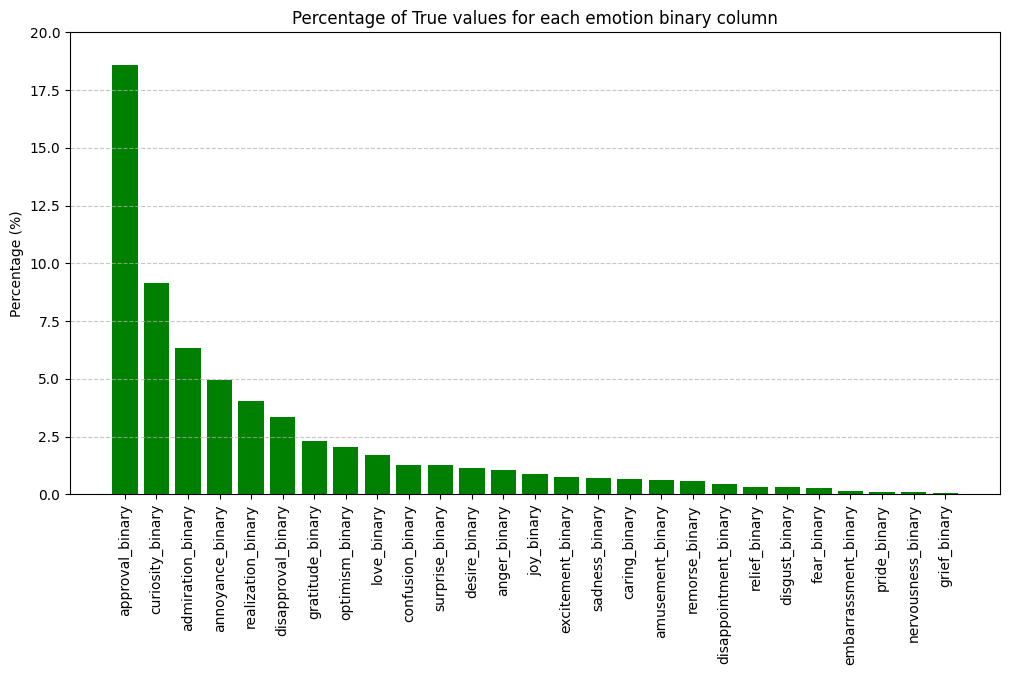

In [ ]:
# binary_columns = ['gratitude_binary', 'excitement_binary', 'joy_binary', 'approval_binary',
#                   'admiration_binary', 'relief_binary', 'caring_binary', 'optimism_binary', 'realization_binary',
#                   'surprise_binary', 'pride_binary', 'desire_binary', 'love_binary', 'annoyance_binary',
#                   'amusement_binary', 'confusion_binary', 'sadness_binary', 'curiosity_binary', 'fear_binary',
#                   'disapproval_binary', 'nervousness_binary', 'disgust_binary', 'disappointment_binary',
#                   'anger_binary', 'grief_binary', 'remorse_binary', 'embarrassment_binary']

# # Calculate percentage of '1' values for each binary column
# percentages = (paragraph_turns_with_emotions[binary_columns].mean() * 100).sort_values(ascending=False)

# # Plot the percentages
# plt.figure(figsize=(12, 6))
# plt.bar(percentages.index, percentages.values, color='green')
# plt.xticks(rotation=90)  # Rotate x-axis labels for better visibility
# plt.ylabel("Percentage (%)")
# plt.title("Percentage of True values for each emotion binary column")
# plt.ylim(0, 20)  # Ensure y-axis goes from 0 to 100%
# plt.grid(axis='y', linestyle='--', alpha=0.7)

# plt.show()

In [11]:
# import matplotlib.pyplot as plt

# # List of columns to plot
# columns_to_plot = ['gratitude', 'excitement', 'joy', 'neutral', 'approval', 'admiration', 'relief', 'caring',
#                    'optimism', 'realization', 'surprise', 'pride', 'desire', 'love', 'annoyance', 'amusement',
#                    'confusion', 'sadness', 'curiosity', 'fear', 'disapproval', 'nervousness', 'disgust',
#                    'disappointment', 'anger', 'grief', 'remorse', 'embarrassment']

# # Plot distributions
# fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20, 25))
# axes = axes.flatten()

# for i, col in enumerate(columns_to_plot):
#     axes[i].hist(paragraph_turns_with_emotions[col].dropna(), bins=30, alpha=0.7, color='blue', edgecolor='black')
#     axes[i].set_title(f'Distribution of {col}')
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel('Frequency')

# plt.tight_layout()
# plt.show()

Compute baseline emotion levels for each episode. Then check how many std's away from the baseline each CA paragraph is.

In [33]:
baseline_emotions = paragraph_turns_with_emotions.groupby('episode_id')[emotion_columns].mean()
baseline_std = paragraph_turns_with_emotions.groupby('episode_id')[emotion_columns].std()
filtered_df = paragraph_turns_with_emotions[paragraph_turns_with_emotions['collectiveAction'] == 0].copy()
for col in emotion_columns:
    filtered_df[f'z_{col}'] = (filtered_df[col] - filtered_df['episode_id'].map(baseline_emotions[col])) / filtered_df['episode_id'].map(baseline_std[col])

In [40]:
z_scores = filtered_df.filter(regex='^z_')
z_scores.describe()

,z_gratitude,z_excitement,z_joy,z_approval,z_admiration,z_relief,z_caring,z_optimism,z_realization,z_surprise,...,z_fear,z_disapproval,z_nervousness,z_disgust,z_disappointment,z_anger,z_grief,z_remorse,z_embarrassment,z_neutral
count,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,...,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000,14944.000000
mean,-0.063857,-0.041444,-0.020658,0.038546,-0.020652,0.106589,0.145364,0.230621,0.360439,-0.004148,...,0.238734,0.161670,0.208318,0.266348,0.283669,0.257989,0.257406,0.240701,0.268653,0.084370
std,0.733884,0.753528,0.788371,0.718993,0.710403,0.866552,0.995128,1.060387,0.999213,0.836801,...,1.330052,0.855782,1.084023,1.133779,1.011599,1.204920,1.098214,1.152122,1.099952,0.694460
min,-1.893453,-2.706796,-1.814919,-1.427236,-1.174752,-1.586131,-1.488049,-1.256907,-1.305114,-3.704829,...,-3.739558,-1.388062,-1.460415,-1.949568,-1.295573,-1.892411,-1.795414,-1.753538,-1.676756,-7.118240
25%,-0.260006,-0.300010,-0.268778,-0.430058,-0.325004,-0.290750,-0.240710,-0.252892,-0.240074,-0.248975,...,-0.205594,-0.308876,-0.236590,-0.209171,-0.254581,-0.238758,-0.253016,-0.174536,-0.251568,-0.343264
50%,-0.191797,-0.218959,-0.196839,-0.134588,-0.231736,-0.128871,-0.150990,-0.127600,0.063847,-0.164843,...,-0.125385,-0.165173,-0.122512,-0.092465,-0.098167,-0.127618,-0.101764,-0.098781,-0.081995,0.129150
75%,-0.124788,-0.103630,-0.109772,0.279031,-0.035748,0.189424,0.061067,0.242402,0.614341,-0.094547,...,0.025131,0.284327,0.170146,0.269067,0.385429,0.194458,0.295939,0.160917,0.355945,0.543132
max,14.984907,11.305042,12.408208,7.987159,10.165960,14.592730,14.515987,13.932778,11.083019,13.784253,...,16.787088,9.877584,16.981340,17.203953,10.835924,14.546223,11.953035,13.908059,15.646368,3.040528


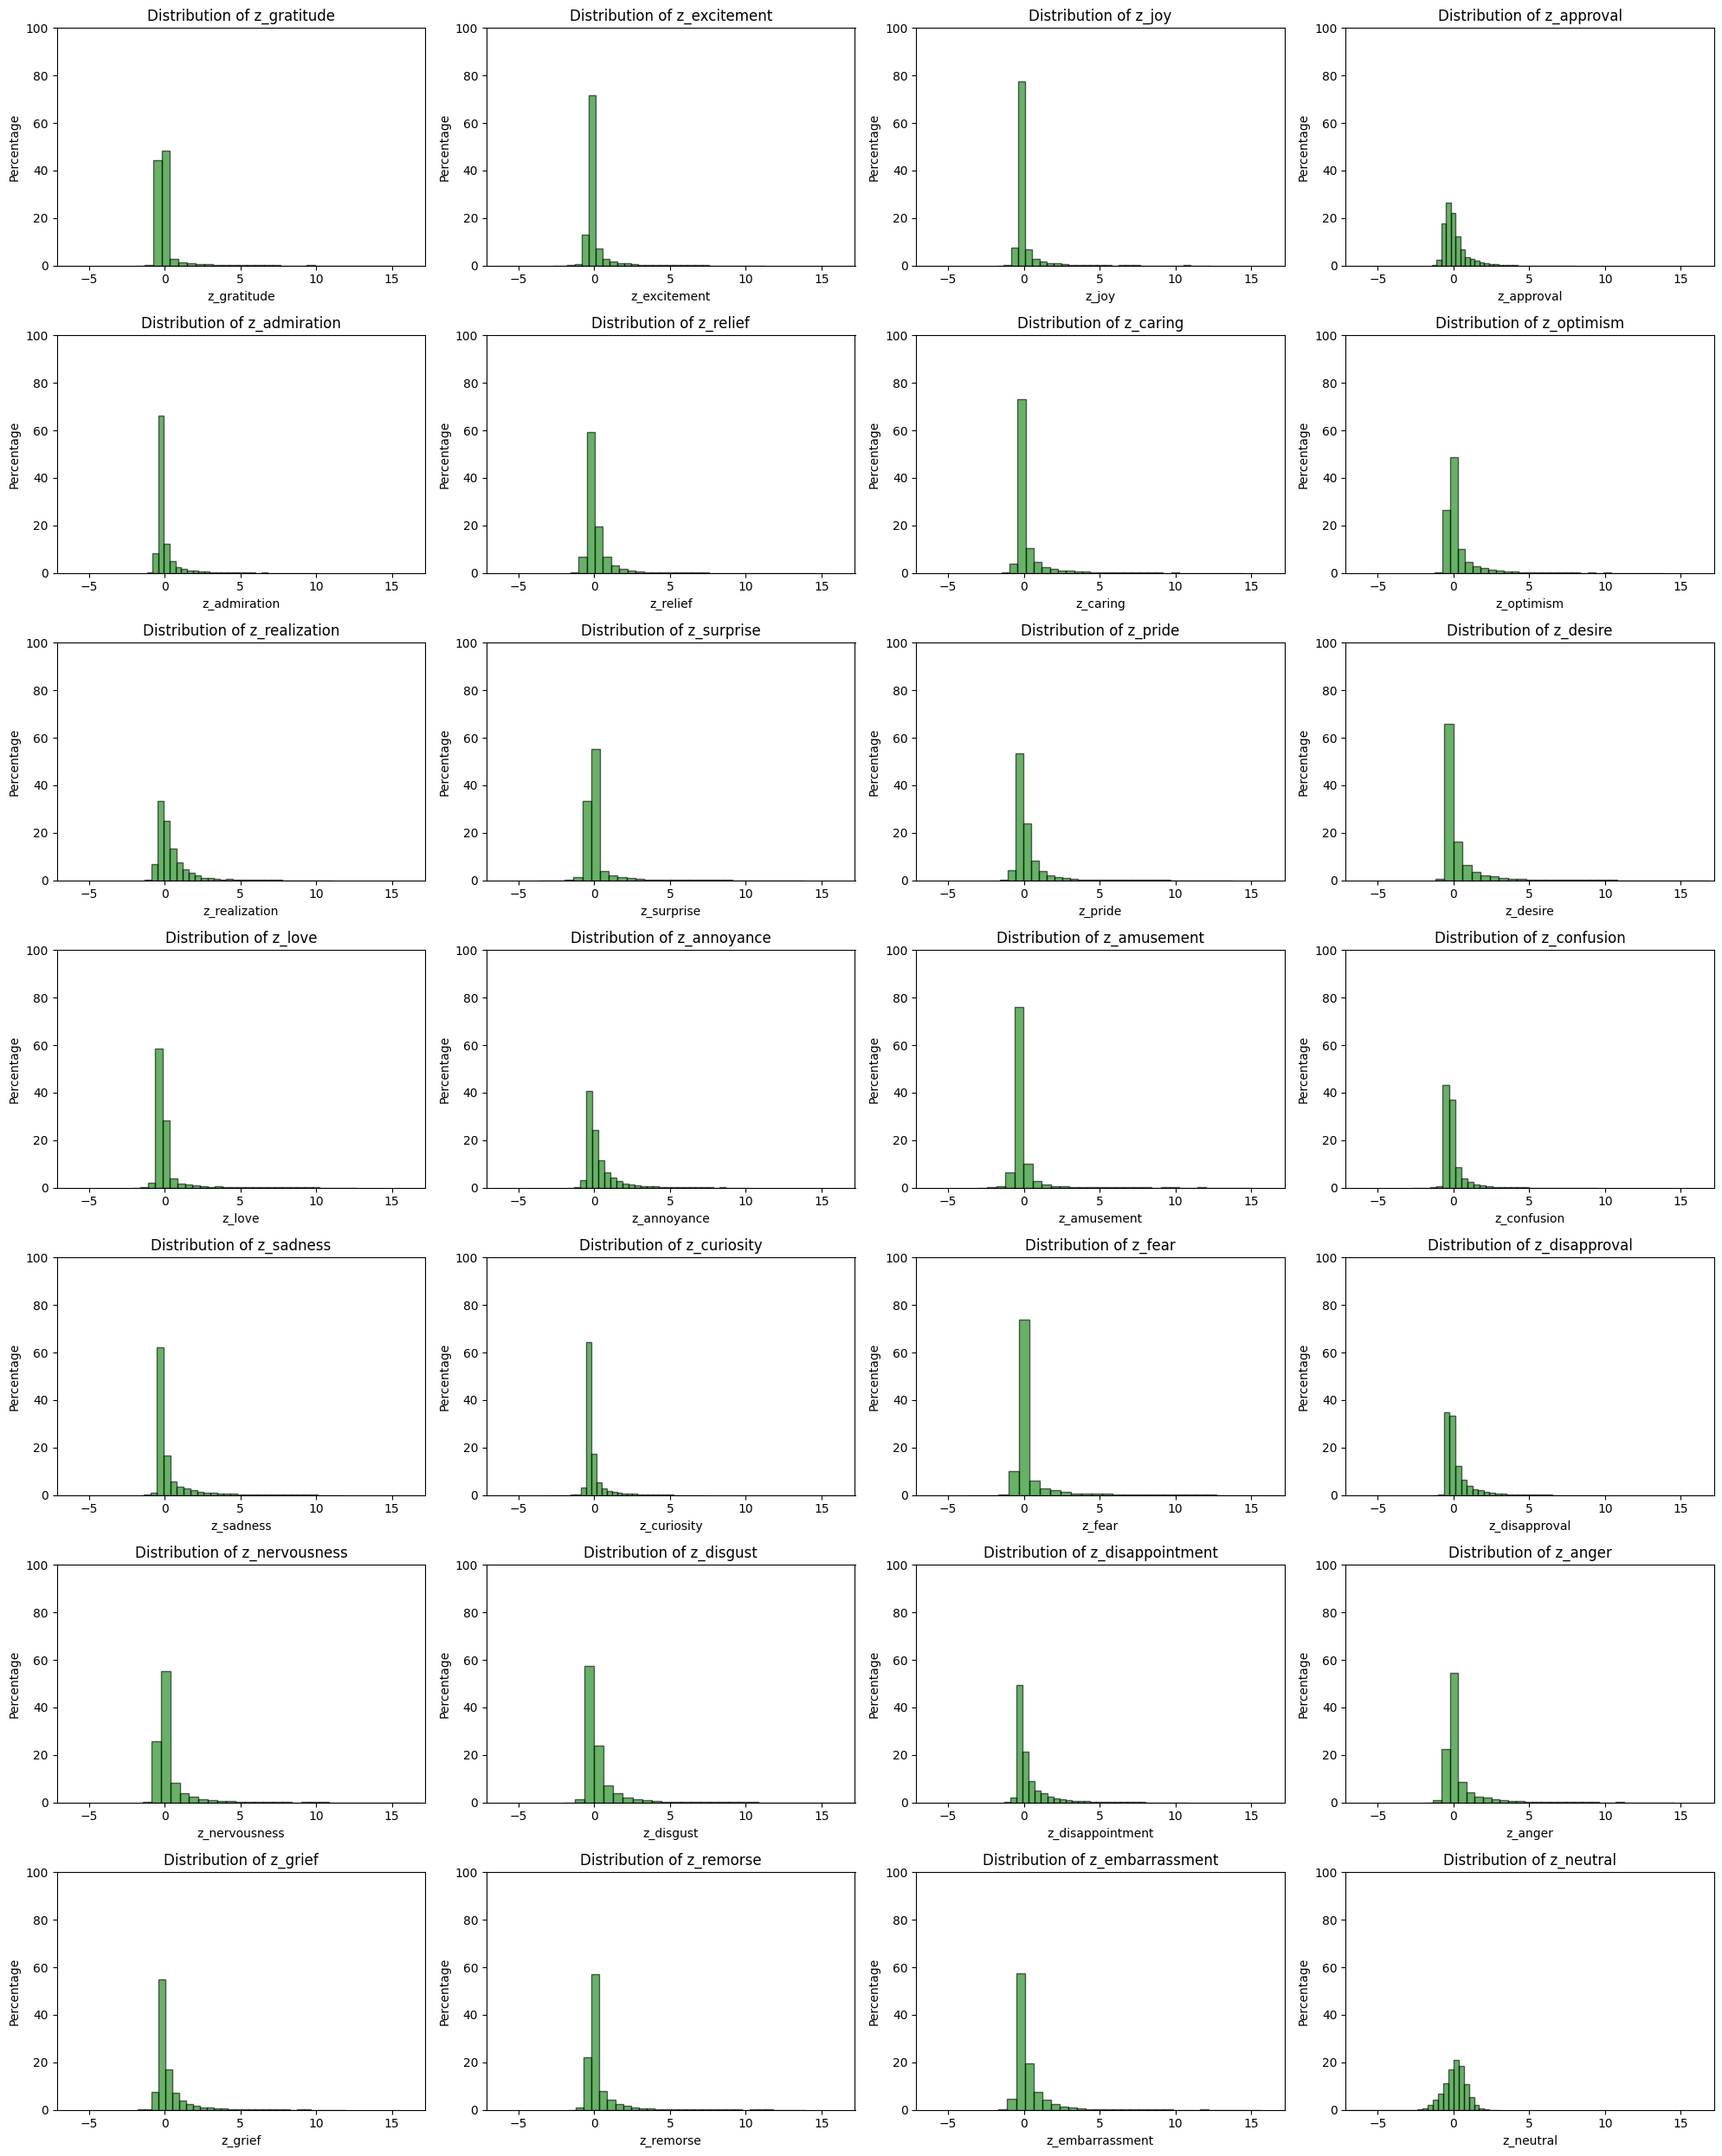

In [ ]:
# Plot distributions of z_scores
fig, axes = plt.subplots(nrows=7, ncols=4, figsize=(20, 25))
axes = axes.flatten()

# Find the global min and max for the x-axis
min_x, max_x = float('inf'), float('-inf')

for i, col in enumerate(z_scores.columns):
    # Drop missing values and calculate the histogram
    data = z_scores[col].dropna()
    counts, bins = np.histogram(data, bins=30)
    
    # Normalize the counts to get percentages
    percentages = (counts / counts.sum()) * 100
    
    # Update the global min and max x-values
    min_x = min(min_x, bins.min())
    max_x = max(max_x, bins.max())

    # Plot the histogram with the calculated percentages
    axes[i].bar(bins[:-1], percentages, width=np.diff(bins), align='edge', color='green', alpha=0.6, edgecolor='black')
    
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage')

# Set the same x-axis scale for all subplots
for ax in axes:
    ax.set_ylim(0, 100)
    ax.set_xlim(min_x, max_x)

plt.tight_layout()
plt.show()

In [37]:
rows_per_episode = filtered_df.groupby('episode_id').size()
rows_per_episode.describe()

count    3543.000000
mean        4.222693
std         4.430762
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        41.000000
dtype: float64

In [ ]:
#print(thresholds)

{'admiration': 0.25, 'amusement': 0.45, 'anger': 0.15, 'annoyance': 0.1, 'approval': 0.3, 'caring': 0.4, 'confusion': 0.55, 'curiosity': 0.25, 'desire': 0.25, 'disappointment': 0.4, 'disapproval': 0.3, 'disgust': 0.2, 'embarrassment': 0.1, 'excitement': 0.35, 'fear': 0.4, 'gratitude': 0.45, 'grief': 0.05, 'joy': 0.4, 'love': 0.25, 'nervousness': 0.25, 'optimism': 0.2, 'pride': 0.1, 'realization': 0.15, 'relief': 0.05, 'remorse': 0.1, 'sadness': 0.4, 'surprise': 0.15, 'neutral': 0.25}


- avg prob per ca and non-ca paragraphs for each episode
- get the difference between them (avg_ca - avg_non)
-  plot difference

In [18]:
baseline_emotions_non = paragraph_turns_with_emotions.loc[paragraph_turns_with_emotions['collectiveAction'] == 1].groupby('episode_id')[emotion_columns].mean()
baseline_emotions_action = paragraph_turns_with_emotions.loc[paragraph_turns_with_emotions['collectiveAction'] == 0].groupby('episode_id')[emotion_columns].mean()
emotion_diff = baseline_emotions_action - baseline_emotions_non
emotion_diff

,gratitude,excitement,joy,approval,admiration,relief,caring,optimism,realization,surprise,...,fear,disapproval,nervousness,disgust,disappointment,anger,grief,remorse,embarrassment,neutral
episode_id,,,,,,,,,,,,,,,,,,,,,
1,-0.003157,-0.011766,0.000540,-0.097596,-0.045261,0.000795,-0.003308,0.007451,0.028784,-0.007338,...,-0.000688,0.070796,0.000341,0.000723,0.123733,0.000293,0.000265,0.000577,0.000342,0.060513
2,-0.000530,-0.002212,-0.009520,-0.140216,0.022258,-0.000906,-0.025423,-0.013023,0.028810,-0.000757,...,0.002263,0.007216,0.000194,0.010142,0.025866,0.013648,0.004668,0.014043,0.003764,-0.083680
4,-0.011119,-0.004525,-0.012153,-0.050255,0.033882,-0.000097,-0.001169,0.022984,0.007327,-0.000318,...,0.012302,0.043366,0.004379,0.004099,0.049925,0.007998,0.000597,-0.000184,0.000436,-0.053159
5,-0.000189,-0.000030,-0.002045,0.057619,-0.038176,0.000942,0.009099,0.054921,0.051424,0.002105,...,0.011971,0.047668,0.001139,0.005192,0.011432,0.004788,0.001139,0.001058,0.002358,-0.066999
6,-0.018003,-0.007863,-0.013230,-0.013240,-0.016184,-0.000879,-0.017413,-0.021438,0.035518,-0.000251,...,0.000298,0.012384,0.000004,0.000904,-0.005913,0.002213,-0.000982,-0.001648,0.000243,0.149440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10484,-0.036553,-0.011564,-0.007875,0.045165,-0.075318,0.002774,0.002282,-0.015683,0.099298,-0.006051,...,-0.000040,-0.012104,0.000620,0.000147,0.000388,-0.000089,0.000442,-0.002906,0.000788,0.018532
10485,-0.001649,-0.011688,-0.006705,-0.043575,-0.000610,-0.000670,-0.000295,0.010746,-0.008369,-0.007656,...,-0.002313,0.027905,-0.000792,-0.005373,0.007108,0.050857,-0.000468,-0.008427,-0.000968,0.015033
10487,-0.006765,-0.014082,-0.014381,0.112528,0.000841,-0.000302,-0.004394,0.007916,0.070422,-0.005585,...,-0.000978,-0.028528,-0.000160,-0.000688,-0.001893,-0.000932,-0.000504,-0.000002,0.000335,0.045914


In [22]:
total_episodes = len(emotion_diff)
percentage_above_zero = {}

for col in emotion_diff.columns:
    count_above_zero = (emotion_diff[col] > 0).sum()
    percentage_above_zero[col] = (count_above_zero / total_episodes) * 100

percentage_df = pd.DataFrame(list(percentage_above_zero.items()), columns=['Emotion', 'Percentage > 0'])
percentage_df.sort_values(by='Percentage > 0', ascending=False)

,Emotion,Percentage > 0
8,realization,71.662433
13,annoyance,64.888513
22,disappointment,62.037821
26,embarrassment,59.074231
27,neutral,57.691222
24,grief,57.578323
21,disgust,55.630821
7,optimism,54.840531
11,desire,54.586509
16,sadness,54.360711


In [97]:
filtered_percentage_df = percentage_df[percentage_df['Percentage > 0'] > 50]
emotions_above_50 = filtered_percentage_df['Emotion'].tolist()
print(emotions_above_50)

['optimism', 'realization', 'pride', 'desire', 'annoyance', 'sadness', 'disapproval', 'disgust', 'disappointment', 'anger', 'grief', 'remorse', 'embarrassment', 'neutral']


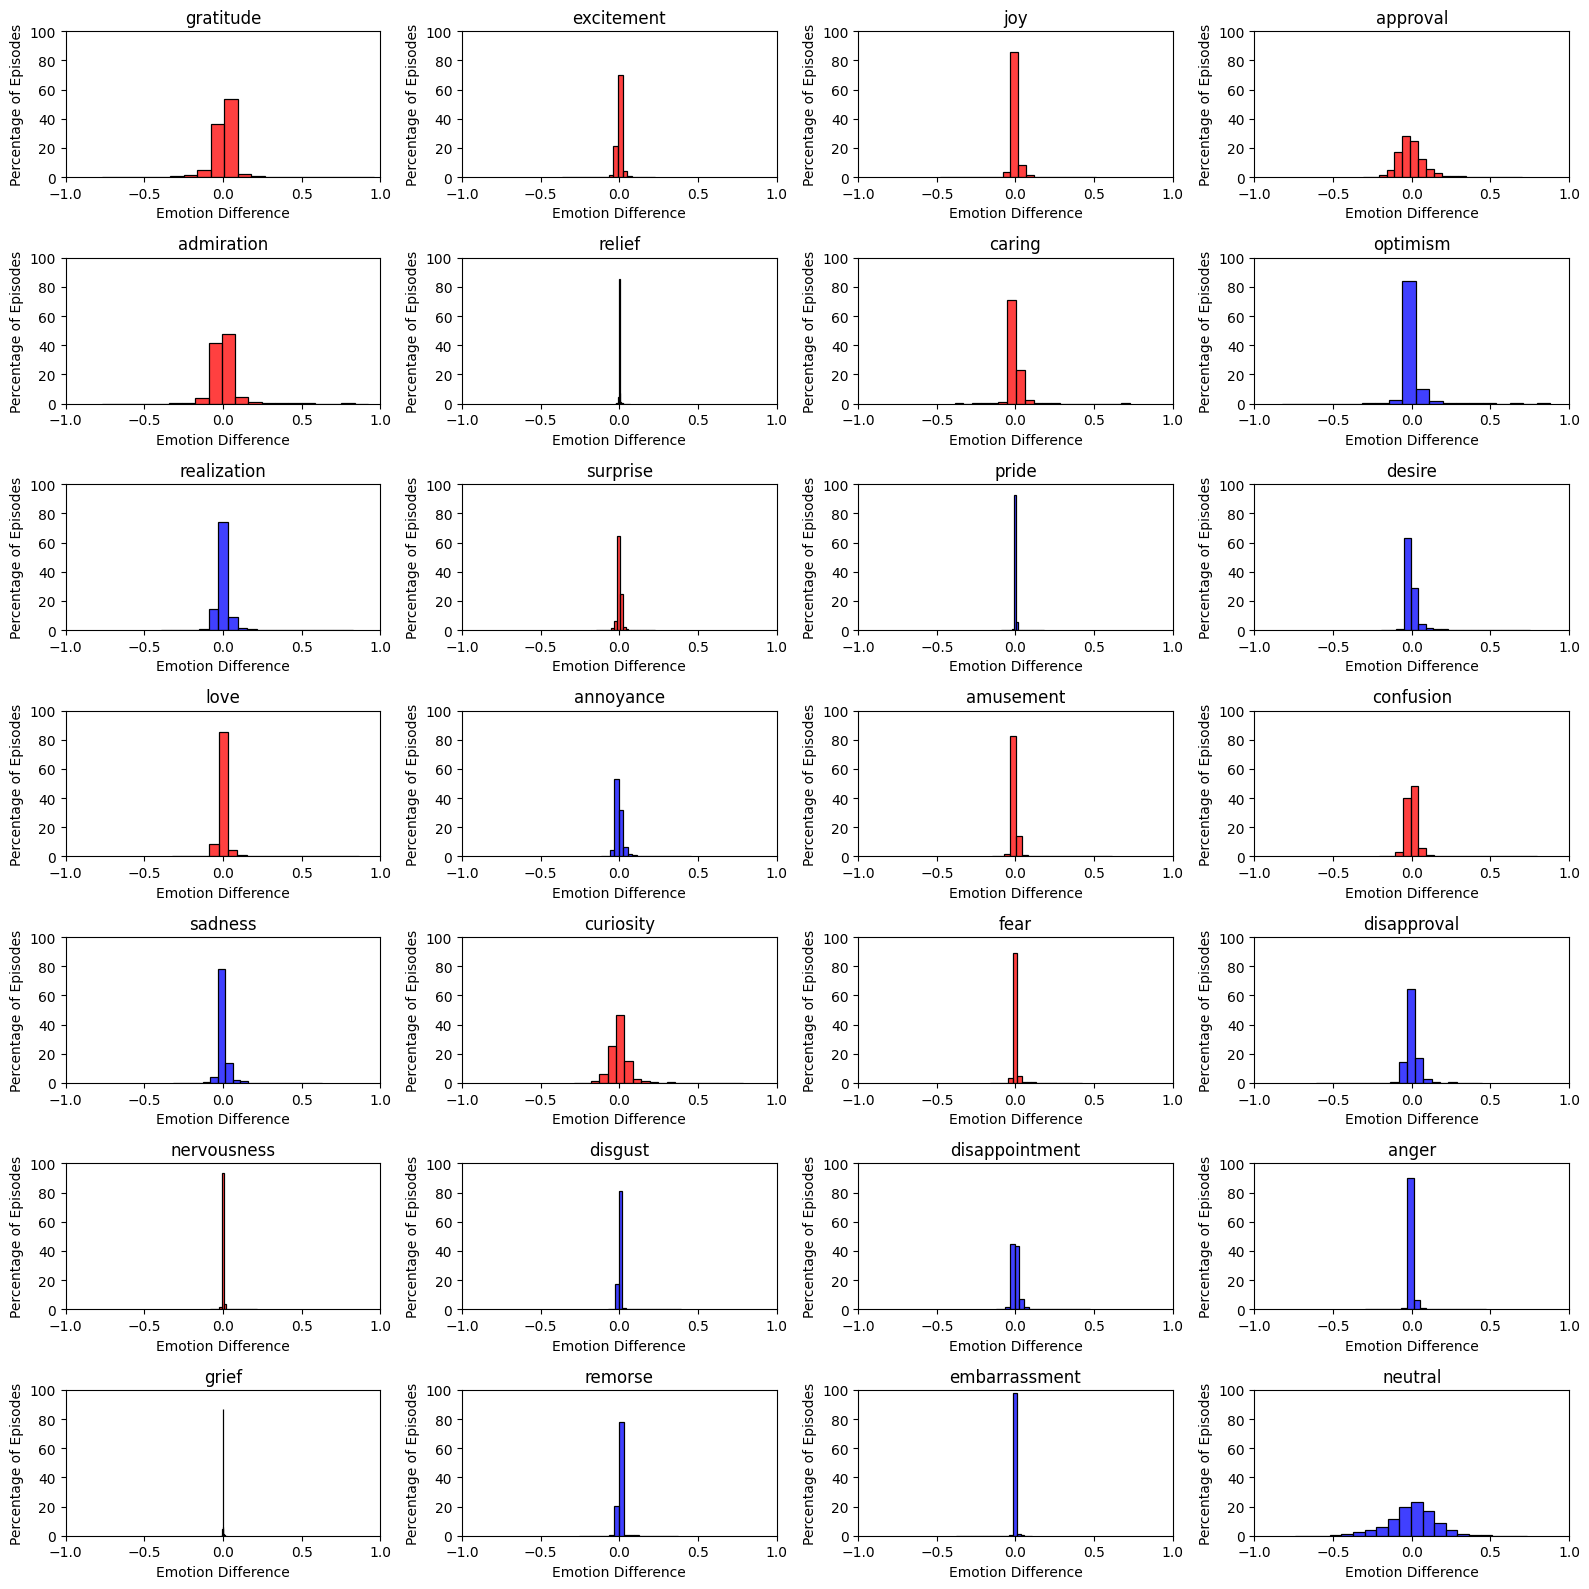

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming `emotion_diff` is your DataFrame
# Make sure to center each column at 0 by subtracting the mean (if not already centered)
emotion_diff_centered = emotion_diff - emotion_diff.mean()

# List of columns to plot in blue
blue_columns = ['optimism', 'realization', 'pride', 'desire', 'annoyance', 'sadness', 
                'disapproval', 'disgust', 'disappointment', 'anger', 'grief', 'remorse', 
                'embarrassment', 'neutral']

# Number of columns to plot
n_cols = emotion_diff_centered.shape[1]

# Set up the plot grid (e.g., 7 rows x 4 columns for 28 columns)
n_rows = n_cols // 4  # Adjust as needed
fig, axes = plt.subplots(n_rows, 4, figsize=(16, 16))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each column
for i, col in enumerate(emotion_diff_centered.columns):
    # Choose color based on the column
    color = 'blue' if col in blue_columns else 'red'
    sns.histplot(emotion_diff_centered[col], kde=False, ax=axes[i], stat="percent", bins=20, color=color)
    axes[i].set_title(col)
    axes[i].set_xlim([-1, 1])  # Adjust x-axis limits as needed
    axes[i].set_ylim([0, 100])  # Percentage from 0 to 100

# Set a common x-axis and y-axis
for ax in axes:
    ax.set_xlabel('Emotion Difference')
    ax.set_ylabel('Percentage of Episodes')

plt.tight_layout()
plt.show()

In [26]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Compute the difference for each emotion
# emotion_diff = baseline_emotions_action - baseline_emotions_non

# # Determine the common x-axis limits to center at 0
# x_max = np.nanmax(np.abs(emotion_diff.values))  # Find max absolute difference
# x_limits = (-x_max, x_max)

# # Plot histograms for each emotion separately
# num_emotions = len(emotion_diff.columns)
# nrows=7
# ncols=4

# fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4*ncols,8*nrows))
# axes=axes.flatten()

# for i, emotion in enumerate(emotion_diff.columns):
#     ax = axes[i] if num_emotions > 1 else axes  # Handle case when there's only one emotion
    
#     # Compute histogram
#     counts, bins, _ = ax.hist(emotion_diff[emotion].dropna(), bins=30, alpha=0.7, edgecolor='black')

#     # Convert counts to percentage
#     total_episodes = len(emotion_diff)  # Total number of episodes
#     percentages = (counts / total_episodes) * 100

#     # Plot histogram with percentages
#     ax.clear()
#     ax.bar(bins[:-1], percentages, width=np.diff(bins), align="edge", alpha=0.7, edgecolor='black')
    
#     # Formatting
#     ax.set_xlim(x_limits)  # Set symmetric x-axis limits
#     ax.axvline(0, color='red', linestyle='dashed', linewidth=1)  # Add vertical line at 0
#     ax.set_title(f"Distribution of Differences for {emotion}")
#     ax.set_xlabel("Difference in Emotion Scores")
#     ax.set_ylabel("Percentage of Episodes (%)")
#     ax.grid(True)

# plt.tight_layout()
# plt.show()

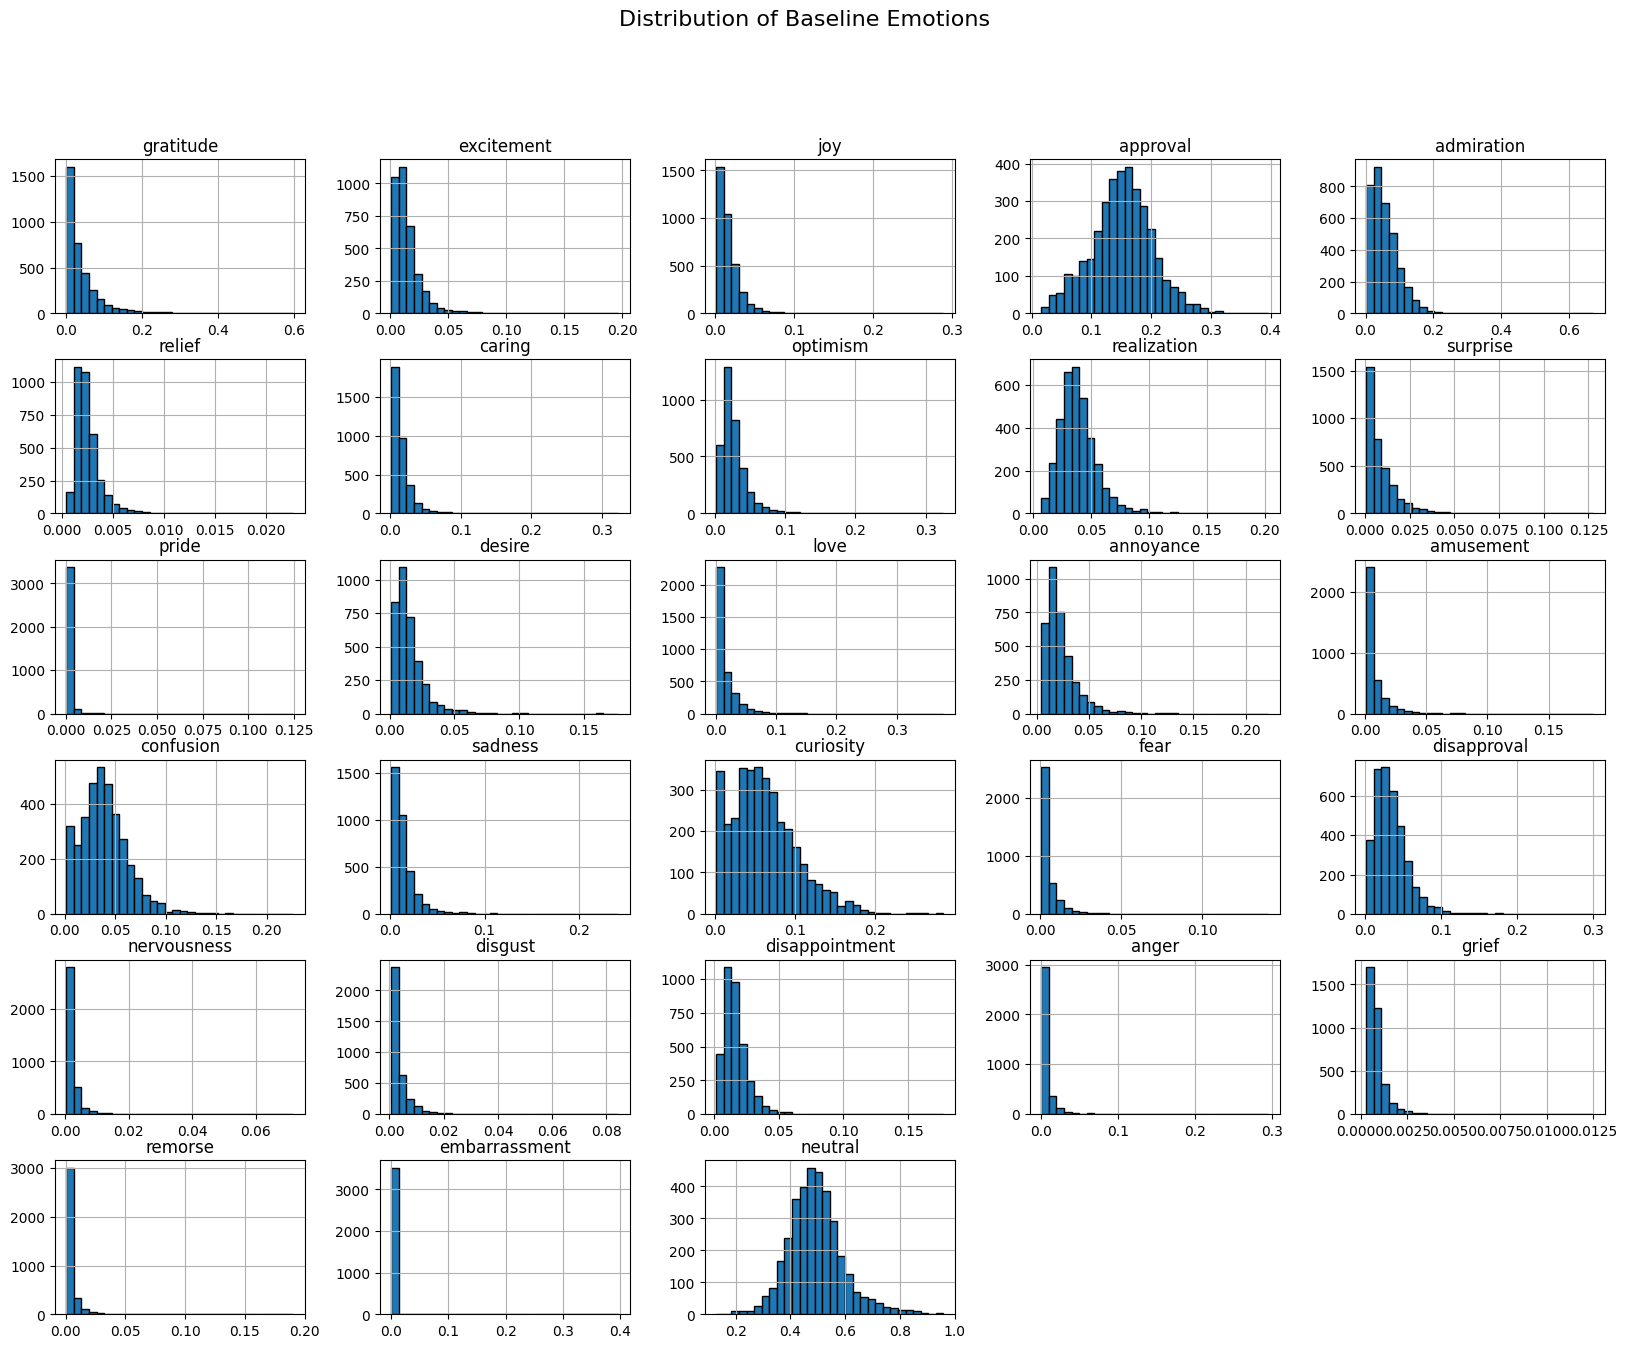

In [27]:
baseline_emotions.hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.suptitle('Distribution of Baseline Emotions', fontsize=16)
plt.show()
# difference between paragraph and baseline in stds

### Title

- you're either with BLM or you're a racist
- You're listening to Hello Bakersfield, the podcast that believes that Black Lives Matter.
- This is episode number 12 and we're starting this off saying black lives matter.
- we stand in solidarity with Black Lives Matter and we'll continue to fight the fight.
- And so I know that you have been very outspoken about the Black Lives Matter protests.
- I am for Black Lives Matter, the movement, and I am for Black people in this country and other minorities being recognized and respected much more than they are in this country
- I am for honestly tearing down racially charged statues
- I am in solidarity with the Black Lives Matter movement and Black people
- I was at several Black Lives Matter protests today.
- How can we actually help to amplify and learn from Black's voices?
- Make sure we get the message spread that black lives matter. We're beautiful, we're worthy. 
- Your hashtag BLM memes are not enough
- I'll say it again, black lives matter
- A fair warning to anyone and everyone who listens to this podcast. Today, we will not hold our tongues. We will not stay silent. Our voices need to be heard because Black Lives Matter.
- Before we start this episode, we wanted to use our platform to show we are a clear ally to the Black Lives Matter movement
- But until episode nine comes out, everybody that's protesting, please be safe. If you're not protesting, continue to spread on social media, the word, donate to different funds if you can and just know that this isn't going to stop until there has changed. And just leave it at that. Black lives matter. I would like to thank you.
- that was what our special Black Lives Matter show was to show how disproportionately black and brown people are put on death row
- That is how you change things
- we cannot continue on with our normal episodes without discussing this issue which is so prevalent in our society right now
- We have people on the back of a truck hunting a Black man.
- We have always been hunted.
- Black people have always been hunted. We never got any reparations or anything
- they want me to educate them on Black Lives Matter
- Why is Black Lives Matter so important?
- That's the reason why we say Black Lives Matter, because at this point in time, we have to just say it plain, because inherently in this country, when people were talking about the fact that all lives matter, they weren't talking about mine, they never have. And some people still aren't. It's not implicit in that statement.
- if my house is on fire and you come to help me put out the fire, but first you got it, you're saying to everybody, like all houses matter.

In [121]:
ca_paragraph_turns = paragraph_turns_with_emotions[paragraph_turns_with_emotions['collectiveAction'] == 0]

In [122]:
blm_paragraphs = ca_paragraph_turns[ca_paragraph_turns['sentence'].str.contains('black lives matter', case=False, na=False)]
len(blm_paragraphs)

2146

In [123]:
with open('../data/title_search_blacklivesmatter.txt', 'w') as file:
    for sentence in blm_paragraphs['sentence']:
        file.write(sentence + '\n')

In [124]:
blm_paragraphs = ca_paragraph_turns[ca_paragraph_turns['sentence'].str.contains('BLM', case=False, na=False)]
len(blm_paragraphs)

65

In [115]:
with open('../data/title_search_blm.txt', 'w') as file:
    for sentence in blm_paragraphs['sentence']:
        file.write(sentence + '\n')

Here I re-compute the label distributions of paragraphs (doesn't make sense does it?)

In [15]:
total_rows = len(paragraph_turns_with_emotions)
collective_action_zero_rows = len(paragraph_turns_with_emotions[paragraph_turns_with_emotions['collectiveAction'] == 0])
percentage_collective_action_zero = (collective_action_zero_rows / total_rows) * 100

print(f"Percentage of rows with collectiveAction = 0: {percentage_collective_action_zero:.2f}%")

Percentage of rows with collectiveAction = 0: 4.34%


In [16]:
total_rows = len(paragraph_turns_with_emotions)
collective_action_zero_rows = len(paragraph_turns_with_emotions[paragraph_turns_with_emotions['racialJustice'] == 1])
percentage_collective_action_zero = (collective_action_zero_rows / total_rows) * 100

print(f"Percentage of rows with racialJustice = 1: {percentage_collective_action_zero:.2f}%")

Percentage of rows with racialJustice = 1: 8.44%


In [19]:
total_rows = len(paragraph_turns_with_emotions)
collective_action_zero_rows = len(paragraph_turns_with_emotions[
    (paragraph_turns_with_emotions['racialJustice'] == 1) & 
    (paragraph_turns_with_emotions['collectiveAction'] == 0)
])
percentage_collective_action_zero = (collective_action_zero_rows / total_rows) * 100

print(f"Percentage of rows with both: {percentage_collective_action_zero:.2f}%")

Percentage of rows with both: 4.34%


### New metrics for all paragraph turns

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from huggingface_hub import PyTorchModelHubMixin
from transformers import AutoModel, AutoTokenizer
import torch.nn.functional as F
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

Sentiment (vader): Compound score > 0.05: Positive sentiment; Compound score < -0.05: Negative sentiment

In [ ]:
analyzer = SentimentIntensityAnalyzer()
def analyze_sentiment(text):
    if isinstance(text, list):  # If text is a list, join into a single string
        text = " ".join(text)
    scores = analyzer.polarity_scores(text)
    return pd.Series([scores["pos"], scores["neg"], scores["compound"]])
paragraph_turns[["pos", "neg", "compound"]] = paragraph_turns["sentence"].apply(analyze_sentiment)

In [ ]:
paragraph_turns['compound'].describe()

In [ ]:
paragraph_turns.to_csv('../data/paragraph_turns_sentiment.csv', index=False)